# CalMS21 end-to-end template

notebook to process CalMS21 data: index raw tracks, convert to standard format, compute features (pair distances/ego, wavelets, global t-SNE), cluster (KMeans/Ward), evaluate against ground truth, and train a local XGBoost behavior model. Fill in the paths/run_ids for your machine.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mosaic.behavior.feature_library import (
    ExtractLabeledTemplates,
    ExtractTemplates,
    GlobalKMeansClustering,
    GlobalScaler,
    GlobalTSNE,
    GlobalWardClustering,
    GroundTruthLabelsSource,
    Inputs,
    ResultColumn,
    TemporalStackingFeature,
    PairEgocentricFeatures,
    PairPoseDistancePCA,
    PairWavelet,
    XgboostFeature,
)
from mosaic.core.analysis import compute_cluster_label_agreement
from mosaic.core.dataset import BEHAVIOR_LABEL_MAP, Dataset
from mosaic.core.pipeline import load_values

# BEHAVIOR_LABEL_MAP  # note that this is currently hard coded for the calms21 dataset

## Dataset setup

In [2]:
DATA_ROOT = Path("/home/paul/ecodylic/minimal_calms21/")

manifest_path = DATA_ROOT / "dataset.yaml"
dataset = Dataset(manifest_path).load()

In [3]:
dataset

Dataset(manifest_path=PosixPath('/home/paul/ecodylic/minimal_calms21/dataset.yaml'), name='calms21-minimal', version='0.1.0', format='yaml', roots={'media': 'videos', 'tracks': 'tracks', 'frames': 'frames', 'features': 'features', 'labels': 'labels', 'models': '/home/paul/ecodylic/minimal_calms21/models'}, meta={}, dataset_type='discrete', segment_duration=None, time_column=None)

## Core feature pipeline (CalMS21)

In [4]:
# Pair pose distance PCA (social distances)

feat_pose = PairPoseDistancePCA(params={"n_components": 6, "pose": {"pose_n": 7}})
pose_result = dataset.run_feature(feat_pose)
print(pose_result)

[feature:pair-posedistance-pca__from__tracks] completed run_id=0.1-05f7657dff -> /home/paul/ecodylic/minimal_calms21/features/pair-posedistance-pca__from__tracks/0.1-05f7657dff
Result(feature='pair-posedistance-pca__from__tracks', run_id='0.1-05f7657dff')


[pair-posedistance-pca__from__tracks] Processed 4/4 sequences


In [5]:
# Pair egocentric kinematics

feat_ego = PairEgocentricFeatures(params={"neck_idx": 3, "tail_base_idx": 6})
ego_result = dataset.run_feature(
    feat_ego, parallel_workers=4, parallel_mode="process"
)
print(ego_result)

[feature:pair-egocentric__from__tracks] completed run_id=0.1-926e064596 -> /home/paul/ecodylic/minimal_calms21/features/pair-egocentric__from__tracks/0.1-926e064596
Result(feature='pair-egocentric__from__tracks', run_id='0.1-926e064596')


[pair-egocentric__from__tracks] Processed 4/4 sequences


In [6]:
## wavelet transformations

wavelet_params = {
    "f_min": 0.2,
    "f_max": 5.0,
    "n_freq": 25,
    "wavelet": "cmor1.5-1.0",
    "log_floor": -3.0,
    "sampling": {"fps_default": 30.0},
}

# Wavelets on PCA (social)
feat_wave_social = PairWavelet(Inputs((pose_result,)), params=wavelet_params)
social_wave_result = dataset.run_feature(
    feat_wave_social, parallel_workers=4, parallel_mode="process"
)
print(social_wave_result)

# Wavelets on egocentric (ego)
feat_wave_ego = PairWavelet(Inputs((ego_result,)), params=wavelet_params)
ego_wave_result = dataset.run_feature(
    feat_wave_ego, parallel_workers=4, parallel_mode="process"
)
print(ego_wave_result)

[pair-wavelet__from__pair-posedistance-pca__from__tracks] Processed 4/4 sequences


[feature:pair-wavelet__from__pair-posedistance-pca__from__tracks] completed run_id=0.1-bf20285f91 -> /home/paul/ecodylic/minimal_calms21/features/pair-wavelet__from__pair-posedistance-pca__from__tracks/0.1-bf20285f91
Result(feature='pair-wavelet__from__pair-posedistance-pca__from__tracks', run_id='0.1-bf20285f91')
[feature:pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.1-11300ef246 -> /home/paul/ecodylic/minimal_calms21/features/pair-wavelet__from__pair-egocentric__from__tracks/0.1-11300ef246
Result(feature='pair-wavelet__from__pair-egocentric__from__tracks', run_id='0.1-11300ef246')


[pair-wavelet__from__pair-egocentric__from__tracks] Processed 4/4 sequences


## Global embedding and clustering

In [7]:
ExtractTemplates.Params.model_fields

{'strategy': FieldInfo(annotation=Literal['random', 'farthest_first'], required=False, default='random'),
 'n_templates': FieldInfo(annotation=int, required=True, metadata=[Ge(ge=1)]),
 'pool': FieldInfo(annotation=PoolConfig, required=False, default_factory=PoolConfig),
 'random_state': FieldInfo(annotation=int, required=False, default=42)}

In [8]:
# 1. fit global scaler on 2000 "random templates", i.e., representative, but random sample

templates = ExtractTemplates(
    Inputs((social_wave_result, ego_wave_result)),
    params={"n_templates": 2000},
)
templates_result = dataset.run_feature(templates)

scaler = GlobalScaler(
    Inputs((social_wave_result, ego_wave_result)),
    params={
        "templates": ExtractTemplates.TemplatesArtifact().from_result(templates_result),
    },
)
scaler_result = dataset.run_feature(scaler)

# 2. fit global tsne on 2000 "farthest-first templates", representative sample with ensured coverage

scaled_templates = ExtractTemplates(
    Inputs((scaler_result,)),
    params={"n_templates": 2000, "strategy": "farthest_first"}
)
scaled_templates_result = dataset.run_feature(scaled_templates)

tsne = GlobalTSNE(
    Inputs((scaled_templates_result,)),
    params={
        "perplexity": 50,
        "templates": ExtractTemplates.TemplatesArtifact().from_result(scaled_templates_result),
    },
)
tsne_result = dataset.run_feature(tsne)

[extract-templates__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 4/4 sequences


[feature:extract-templates__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.1-5448a893aa -> /home/paul/ecodylic/minimal_calms21/features/extract-templates__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.1-5448a893aa


[global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 4/4 sequences


[feature:global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.1-abc1b17ff3 -> /home/paul/ecodylic/minimal_calms21/features/global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.1-abc1b17ff3


[extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 4/4 sequences


[feature:extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.1-69291681e4 -> /home/paul/ecodylic/minimal_calms21/features/extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.1-69291681e4
[feature:global-tsne__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.4-41ead27717 -> /home/paul/ecodylic/minimal_calms21/features/global-tsne__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.4-41ead27717


[global-tsne__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 4/4 sequences


In [9]:
# k-means below uses the same features (could also define as variable once and reuse)

# also note that each feature now needs to define its "artifacts" that are written to disk but are not per-frame outputs
# these are defined as dataclasses within the feature class body, and implement a from_result() to directly retrieve from a previous feature run

kmeans_results = []
for k in [50, 100]:
    kmeans = GlobalKMeansClustering(
        Inputs((scaled_templates_result,)),
        params={
            "k": int(k),
            "templates": ExtractTemplates.TemplatesArtifact().from_result(scaled_templates_result),
            "label_artifact_points": True,
        },
    )
    k_result = dataset.run_feature(kmeans)
    kmeans_results.append({"k": int(k), "run": k_result})
    print(k_result)

[global-kmeans__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 4/4 sequences


[feature:global-kmeans__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.4-c7612cc81b -> /home/paul/ecodylic/minimal_calms21/features/global-kmeans__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.4-c7612cc81b
Result(feature='global-kmeans__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks', run_id='0.4-c7612cc81b')
[feature:global-kmeans__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.4-ec5c64cf92 -> /home/paul/ecodylic/minimal_calms21/features/global-kmeans__from__extract-templates__from__global-scaler__from__pai

[global-kmeans__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 4/4 sequences


Tip: `kmeans_results` holds multiple runs; select a specific `run_id` (e.g., `kmeans_results[0]['run'].run_id`) when you need a stable reference.


In [10]:
ward_results = []
for cut in [25, 50, 100]:
    ward = GlobalWardClustering(
        Inputs((scaled_templates_result,)),
        params={
            "templates": ExtractTemplates.TemplatesArtifact().from_result(scaled_templates_result),
            "method": "ward",
            "n_clusters": cut,
        }
    )
    ward_result = dataset.run_feature(ward)
    print(ward_result)
    ward_results.append(ward_result)

[global-ward__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 4/4 sequences


[feature:global-ward__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.3-a5e2a80da7 -> /home/paul/ecodylic/minimal_calms21/features/global-ward__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.3-a5e2a80da7
Result(feature='global-ward__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks', run_id='0.3-a5e2a80da7')


[global-ward__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 4/4 sequences


[feature:global-ward__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.3-f08b026ba7 -> /home/paul/ecodylic/minimal_calms21/features/global-ward__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.3-f08b026ba7
Result(feature='global-ward__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks', run_id='0.3-f08b026ba7')
[feature:global-ward__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.3-c00efc82a7 -> /home/paul/ecodylic/minimal_calms21/features/global-ward__from__extract-templates__from__global-scaler__from__pair-wavelet_

[global-ward__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 4/4 sequences


## Cluster/label agreement (GT vs clusters)

Exploratory data analysis step

In [11]:
kmeans_feature = k_result.feature
run_id = k_result.run_id

agr = compute_cluster_label_agreement(
    dataset,
    cluster_feature=kmeans_feature,
    cluster_run_id=run_id,
    label_kind="behavior",
    sequences=None,
)
agr

{'cluster_feature': 'global-kmeans__from__extract-templates__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks',
 'cluster_run_id': '0.4-ec5c64cf92',
 'label_kind': 'behavior',
 'n_sequences': 4,
 'n_frames_total': 112778,
 'n_frames_used': 112778,
 'sampled': False,
 'metrics': {'n_samples': 112778,
  'n_classes': 4,
  'n_clusters': 100,
  'ARI': 0.014011065050417028,
  'AMI': 0.1560677301912699,
  'homogeneity': 0.4705075317969567,
  'completeness': 0.09386572731324816,
  'v_measure': 0.15650823622689958,
  'purity': 0.8098210643919913,
  'hungarian_accuracy': 0.0595506215751299,
  'confusion': array([[   0,    0,  118,   48, 1104,    0,  886,    0,    0,    0,   30,
           530,   10,    2,  364,  178,   34,  506,    0,    0,    0,    0,
             6,    0,    0,    0,   86,    0, 1196,    0,    0,   82,    0,
             0,    0,    0,  178,    0,    0,    0,    2,   96,  992,    0,
           

## Visualizations (GT + clusters on t-SNE)

In [12]:
df = load_values(
    dataset,
    [
        ResultColumn(column="tsne_x").from_result(tsne_result),
        ResultColumn(column="tsne_y").from_result(tsne_result),
        ResultColumn(column="cluster").from_result(k_result),
        GroundTruthLabelsSource(),
    ]
)

print(df.columns.tolist())

['group', 'id1', 'frame', 'id2', 'sequence', 'tsne_x', 'tsne_y', 'cluster', 'labels-behavior']


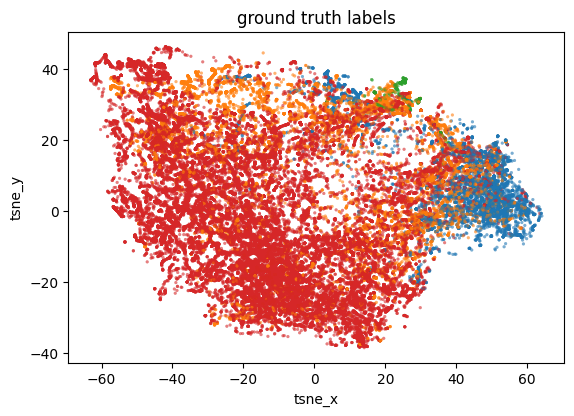

In [13]:
import seaborn as sns

scatter = sns.scatterplot(
    data=df,
    x="tsne_x",
    y="tsne_y",
    hue="labels-behavior",
    palette=sns.color_palette(n_colors=df["labels-behavior"].nunique()),
    lw=0,
    s=5,
    alpha=0.2,
    legend=None,
)

plt.gca().set_aspect("equal")
plt.title("ground truth labels")

plt.show()

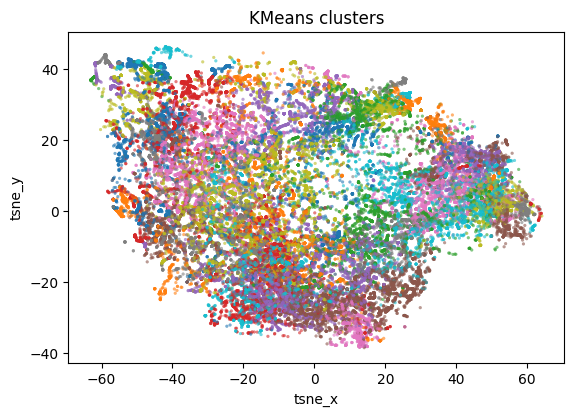

In [14]:
scatter = sns.scatterplot(
    data=df,
    x="tsne_x",
    y="tsne_y",
    hue="cluster",
    palette=sns.color_palette(n_colors=df["cluster"].nunique()),
    lw=0,
    s=5,
    alpha=0.2,
    legend=None,
)

plt.gca().set_aspect("equal")
plt.title("KMeans clusters")

plt.show()

## Supervised classification (XGBoost)

Uses the new feature-based pipeline: `GlobalScaler -> ExtractLabeledTemplates -> XgboostFeature`. No separate model library, no manual train/test splitting, no internal scaling.

### Temporal stacking on scaled features

Builds temporal context by stacking Gaussian-smoothed neighboring frames at time offsets. Can optionally add pooled statistics (mean, std) over a sliding window. Runs on the already-scaled wavelet features.

In [15]:
# Temporal stack over scaled wavelet features
ts_stack = TemporalStackingFeature(
    Inputs((scaler_result,)),
    params={
        "half": 2,
        "skip": 1,
        "use_temporal_stack": True,
        "sigma_stack": 2,
        "add_pool": False,
        "pool_stats": ("mean",),
        "fps": 30.0,
    },
)
ts_stack_result = dataset.run_feature(
    ts_stack,
    parallel_workers=4,
    parallel_mode="thread",
)
print(ts_stack_result)

[feature:temporal-stack__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.3-4f083bd8d4 -> /home/paul/ecodylic/minimal_calms21/features/temporal-stack__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.3-4f083bd8d4
Result(feature='temporal-stack__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks', run_id='0.3-4f083bd8d4')


[temporal-stack__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 4/4 sequences


### Extract labeled templates + train XGBoost

`ExtractLabeledTemplates` subsamples the temporal-stacked features, aligns ground truth labels from NPZ files, and assigns train/test splits by sequence. `XgboostFeature` trains on the labeled templates and runs per-sequence inference -- all through `run_feature`.

In [16]:
# 1. Extract labeled templates from temporal-stacked scaled features
labeled_templates = ExtractLabeledTemplates(
    Inputs((ts_stack_result,)),
    params={
        "labels": GroundTruthLabelsSource(),
        "n_per_class": 500,
        "test_fraction": 0.2,
    },
)
labeled_templates_result = dataset.run_feature(labeled_templates)
print(labeled_templates_result)

# 2. Train XGBoost + run per-sequence inference
xgb = XgboostFeature(
    Inputs((ts_stack_result,)),
    params={
        "templates": ExtractLabeledTemplates.LabeledTemplatesArtifact().from_result(labeled_templates_result),
        "strategy": "multiclass",
        "default_class": 3,  # "other" is the majority/default class
        "n_estimators": 10,  # very short fit for demo
        "max_depth": 3,
    },
)
xgb_result = dataset.run_feature(xgb)
print(xgb_result)

[extract-labeled-templates__from__temporal-stack__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 4/4 sequences


[feature:extract-labeled-templates__from__temporal-stack__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.1-a417c03d33 -> /home/paul/ecodylic/minimal_calms21/features/extract-labeled-templates__from__temporal-stack__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.1-a417c03d33
Result(feature='extract-labeled-templates__from__temporal-stack__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks', run_id='0.1-a417c03d33')
[feature:xgboost__from__temporal-stack__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] completed run_id=0.1-c025ba076a -> /home/paul/ecodylic/minimal_calms21/features/xgboost__from__temporal-stack__from__global-scaler__

[xgboost__from__temporal-stack__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks] Processed 4/4 sequences


In [17]:
# Inspect evaluation metrics (written when test split is present)
from mosaic.core.pipeline.run import feature_run_root

xgb_run_root = feature_run_root(dataset, xgb_result.feature, xgb_result.run_id)
reports_path = xgb_run_root / "reports.json"
summary_path = xgb_run_root / "summary.csv"

print("run root:", xgb_run_root)
print("reports.json:", reports_path.exists())
print("summary.csv:", summary_path.exists())

run root: /home/paul/ecodylic/minimal_calms21/features/xgboost__from__temporal-stack__from__global-scaler__from__pair-wavelet__from__pair-posedistance-pca__from__tracks+pair-wavelet__from__pair-egocentric__from__tracks/0.1-c025ba076a
reports.json: True
summary.csv: True


In [18]:
if summary_path.exists():
    summary_df = pd.read_csv(summary_path)
    display(summary_df)

if reports_path.exists():
    with open(reports_path) as f:
        reports = json.load(f)
    print(json.dumps(reports, indent=2))

,Unnamed: 0,precision,recall,f1-score,support
0,0,0.296703,0.054000,0.091371,500.000000
1,1,0.385735,0.530000,0.446504,500.000000
2,2,0.281250,0.592105,0.381356,228.000000
3,3,0.687234,0.646000,0.665979,500.000000
4,accuracy,0.434028,0.434028,0.434028,0.434028
5,macro avg,0.412731,0.455526,0.396302,1728.000000
6,weighted avg,0.433427,0.434028,0.398655,1728.000000


{
  "0": {
    "precision": 0.2967032967032967,
    "recall": 0.054,
    "f1-score": 0.09137055837563451,
    "support": 500.0
  },
  "1": {
    "precision": 0.38573508005822416,
    "recall": 0.53,
    "f1-score": 0.44650379106992416,
    "support": 500.0
  },
  "2": {
    "precision": 0.28125,
    "recall": 0.5921052631578947,
    "f1-score": 0.3813559322033898,
    "support": 228.0
  },
  "3": {
    "precision": 0.6872340425531915,
    "recall": 0.646,
    "f1-score": 0.6659793814432989,
    "support": 500.0
  },
  "accuracy": 0.4340277777777778,
  "macro avg": {
    "precision": 0.41273060482867807,
    "recall": 0.45552631578947367,
    "f1-score": 0.39630241577306186,
    "support": 1728.0
  },
  "weighted avg": {
    "precision": 0.4334266259591182,
    "recall": 0.4340277777777778,
    "f1-score": 0.3986551030016213,
    "support": 1728.0
  }
}


### Visualize predictions on t-SNE

Load XGBoost predictions alongside t-SNE coordinates and ground truth labels.

In [19]:
df_pred = load_values(
    dataset,
    [
        ResultColumn(column="predicted_label").from_result(xgb_result),
        ResultColumn(column="split").from_result(labeled_templates_result),
        ResultColumn(column="tsne_x").from_result(tsne_result),
        ResultColumn(column="tsne_y").from_result(tsne_result),
        GroundTruthLabelsSource(),
    ],
)

df_test = df_pred[df_pred["split"] == "test"]
df_train = df_pred[df_pred["split"] == "train"]
print(f"{len(df_pred)} total, {len(df_train)} train, {len(df_test)} test")
print(df_pred.columns.tolist())

451112 total, 350816 train, 100296 test
['group', 'id1', 'frame', 'id2', 'sequence', 'predicted_label', 'split', 'tsne_x', 'tsne_y', 'labels-behavior']


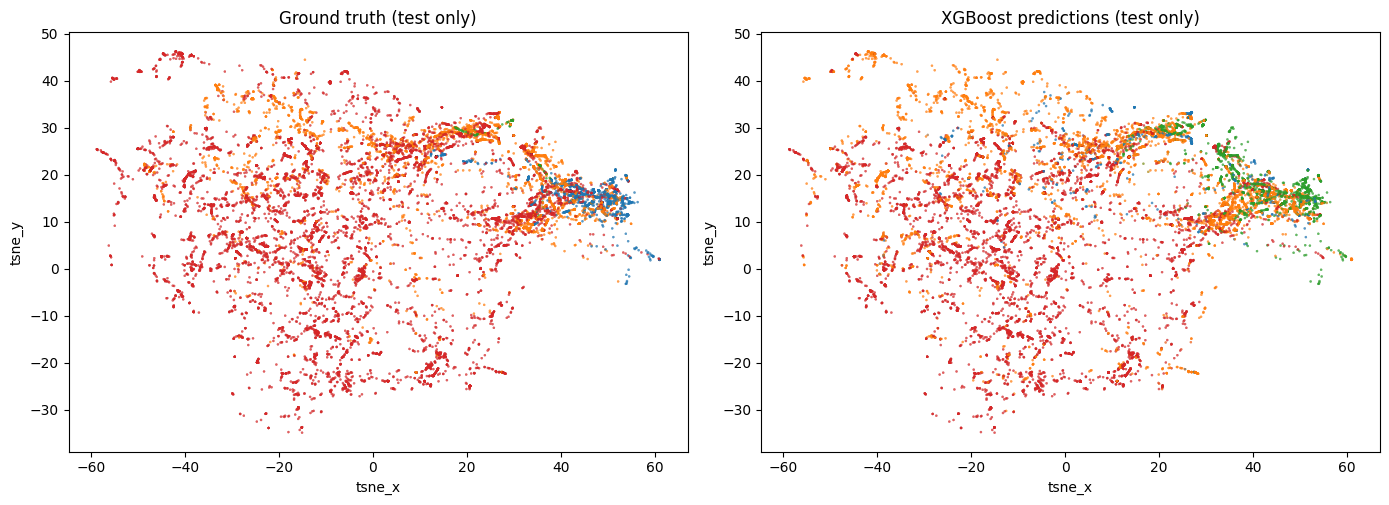

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, title in [
    (axes[0], "labels-behavior", "Ground truth (test only)"),
    (axes[1], "predicted_label", "XGBoost predictions (test only)"),
]:
    sns.scatterplot(
        data=df_test,
        x="tsne_x",
        y="tsne_y",
        hue=col,
        palette=sns.color_palette(n_colors=int(df_test[col].nunique())),
        lw=0,
        s=3,
        alpha=0.15,
        legend=None,
        ax=ax,
    )
    ax.set_aspect("equal")
    ax.set_title(title)

plt.tight_layout()
plt.show()

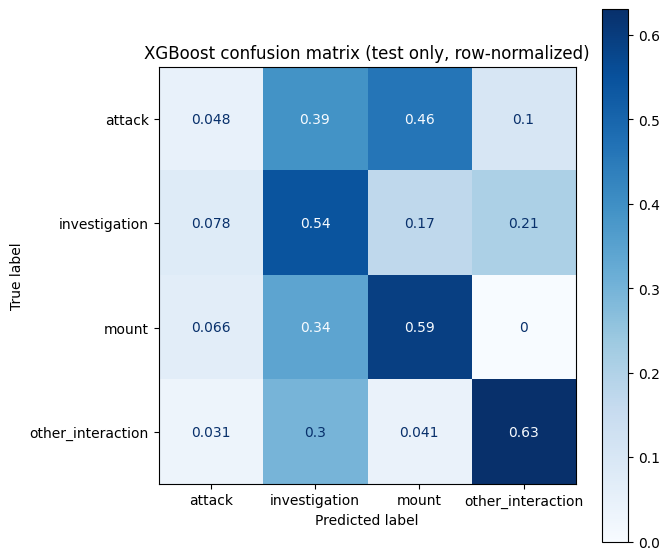

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

y_true = df_test["labels-behavior"].values
y_pred = df_test["predicted_label"].values
label_names = [BEHAVIOR_LABEL_MAP.get(i, str(i)) for i in sorted(df_test["labels-behavior"].unique())]

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=label_names,
    normalize="true",
    cmap="Blues",
    ax=ax,
)
ax.set_title("XGBoost confusion matrix (test only, row-normalized)")
plt.tight_layout()
plt.show()